In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
f='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-22-00000/w_mpas_prt_dyamond.2016-08-22-00000.nc'
#f='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-22-00000/w_mpas_dyamond.nc'
ftopo='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/TimeInvariant/PHIS_dyamond.nc'

In [3]:
X=xr.open_dataset( f )
Topo=xr.open_dataset( ftopo )

In [4]:
X

<xarray.Dataset> Size: 11GB
Dimensions:     (ncol: 41943042, time: 1, ilev: 59)
Coordinates:
  * time        (time) object 8B 2016-08-22 00:00:00
  * ilev        (ilev) float64 472B 4.343e+04 3.88e+04 3.494e+04 ... 70.0 0.0
Dimensions without coordinates: ncol
Data variables:
    lon         (ncol) float64 336MB ...
    lat         (ncol) float64 336MB ...
    w_mpas_prt  (time, ilev, ncol) float32 10GB ...

In [5]:
latmin, latmax = -60., -30.
lonmin, lonmax = 0., 90.   # if using 0-360 longitude

mask = (
    (X.lat >= latmin) &
    (X.lat <= latmax) &
    (X.lon >= lonmin) &
    (X.lon <= lonmax)
)

X_sub = X.sel(ncol=mask)
Topo_sub=Topo.sel(ncol=mask)

In [6]:

target_heights = [1_000, 5_000, 10_000, 20_000, 25_000]  # meters

# Use whichever dim your dataset has
lev_coord = "ilev" if "ilev" in X_sub.dims else "lev"
heights = X_sub[lev_coord].values  # 1D array of heights in meters

# Find nearest level index for each target
lev_indices = [np.argmin(np.abs(heights - h)) for h in target_heights]
lev_values  = heights[lev_indices]

# Sanity check
for t, i, v in zip(target_heights, lev_indices, lev_values):
    print(f"Target {t:>6}m → index {i:>3}, actual {v:.1f}m")

# Select those levels
X_subz = X_sub.isel({lev_coord: lev_indices})

Target   1000m → index  47, actual 995.9m
Target   5000m → index  33, actual 5244.9m
Target  10000m → index  23, actual 10248.3m
Target  20000m → index   8, actual 20573.1m
Target  25000m → index   5, actual 26003.6m


In [7]:
X_subz

<xarray.Dataset> Size: 69MB
Dimensions:     (ncol: 1924247, time: 1, ilev: 5)
Coordinates:
  * time        (time) object 8B 2016-08-22 00:00:00
  * ilev        (ilev) float64 40B 995.9 5.245e+03 1.025e+04 2.057e+04 2.6e+04
Dimensions without coordinates: ncol
Data variables:
    lon         (ncol) float64 15MB 89.96 90.0 90.0 89.91 ... 45.02 44.99 44.99
    lat         (ncol) float64 15MB -58.29 -58.28 -58.31 ... -35.28 -35.25
    w_mpas_prt  (time, ilev, ncol) float32 38MB ...

In [8]:
%%time
lon,lat,topo = Topo_sub.lon.values , Topo_sub.lat.values , Topo_sub.PHIS.values /9.8

CPU times: user 38.4 s, sys: 237 ms, total: 38.6 s
Wall time: 42.1 s


CPU times: user 16 s, sys: 667 ms, total: 16.7 s
Wall time: 18.7 s


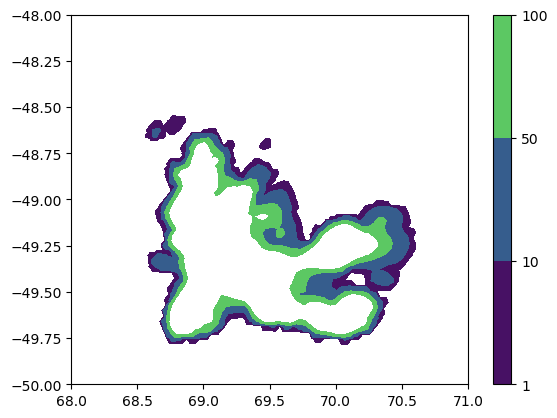

In [9]:
%%time
plt.tricontourf( lon, lat , topo, levels=[1,10,50,100]  ) 
plt.xlim( 68,71)
plt.ylim( -50,-48 ) 
plt.colorbar()

In [10]:
from scipy.interpolate import griddata
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import Delaunay

# Regrid a single 2D field (e.g. a surface variable)
def regrid_field(data_1d):
    return griddata(points, data_1d, (lon2d, lat2d), method="linear")



In [11]:
%%time
# Define your target regular grid
lat_res, lon_res = 0.025, 0.025  # degrees — tune to taste (0.05 ≈ ~5km, close to your 3km native)

lat_out = np.arange(latmin, latmax, lat_res)
lon_out = np.arange(lonmin, lonmax, lon_res)
lon2d, lat2d = np.meshgrid(lon_out, lat_out)

# Source points (from your subsampled dataset)
lat_in = lat # np.degrees(ds_sub["latCell"].values)
lon_in = lon #np.degrees(ds_sub["lonCell"].values)
points = np.column_stack((lon_in, lat_in))

topo_2D = griddata(points, topo, (lon2d, lat2d), method="linear")


interp = LinearNDInterpolator(points, np.zeros(len(lat_in)))  # dummy values to build triangulation

target_points = np.column_stack((lon2d.ravel(), lat2d.ravel()))









tri = Delaunay(points)
interp = LinearNDInterpolator(tri, np.zeros(len(lat_in)))  # reuse triangulation

def regrid_fast(data_1d):
    """Swap in new data values, apply pre-built weights."""
    interp.values = data_1d[:, np.newaxis].astype(np.float64)
    return interp(lon2d, lat2d)

# Example: single time step, surface field
#field = ds_sub["t2m"].isel(Time=0).values  # shape: (nCells,)
#field_regridded = regrid_field(field)       # shape: (nlat, nlon)

CPU times: user 1min 12s, sys: 1.26 s, total: 1min 14s
Wall time: 1min 20s


CPU times: user 159 ms, sys: 92 μs, total: 160 ms
Wall time: 161 ms


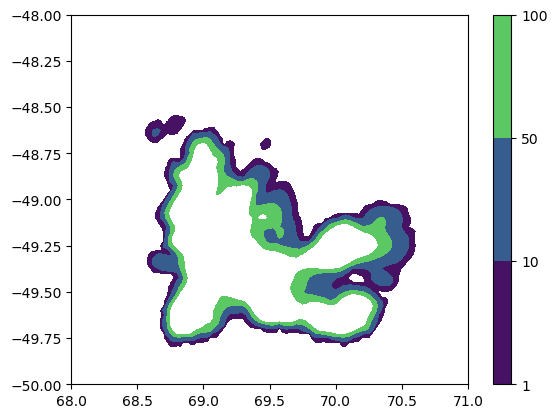

In [12]:
%%time
plt.contourf( lon2d, lat2d , topo_2D ,levels=[1,10,50,100]) 
#plt.contourf( topo_2D, levels=[1,10,50,100] ) 
plt.xlim( 68,71)
plt.ylim( -50,-48 ) 
#plt.ylim(400,500)
plt.colorbar()

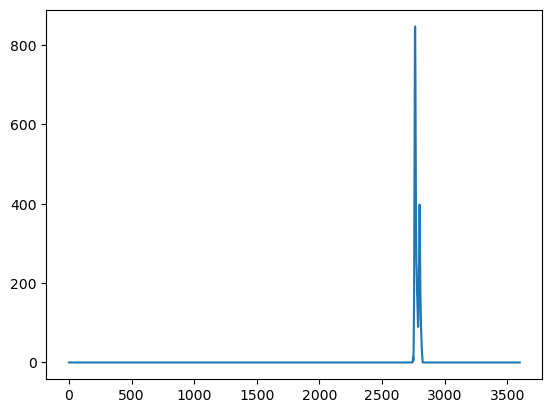

In [13]:
plt.plot(topo_2D[428,:] )

In [14]:
%%time
wp=X_subz.w_mpas_prt.values
#wp=X_subz.w_mpas.values


CPU times: user 2min 46s, sys: 251 ms, total: 2min 46s
Wall time: 3min 4s


In [15]:
%%time
import numpy as np
from scipy.spatial import Delaunay
# Source points (from your subsampled dataset)
lat_in = lat # np.degrees(ds_sub["latCell"].values)
lon_in = lon #np.degrees(ds_sub["lonCell"].values)
points = np.column_stack((lon_in, lat_in))

# ── 1. SOURCE POINTS (done once) ─────────────────────────────────────────────
lat_in = lat # np.degrees(ds_sub["latCell"].values)
lon_in = lon #np.degrees(ds_sub["lonCell"].values)
points = np.column_stack((lon_in, lat_in))

# ── 2. TARGET GRID (done once) ───────────────────────────────────────────────
lat_res, lon_res = 0.025, 0.025  # degrees — tune to taste (0.05 ≈ ~5km, close to your 3km native)
lat_out = np.arange(latmin, latmax, lat_res)
lon_out = np.arange(lonmin, lonmax, lon_res)
lon2d, lat2d = np.meshgrid(lon_out, lat_out)
target_points = np.column_stack((lon2d.ravel(), lat2d.ravel()))

# ── 3. BUILD WEIGHTS (done once) ─────────────────────────────────────────────
tri = Delaunay(points)
simplex = tri.find_simplex(target_points)        # which triangle each target point is in
vertices = tri.simplices[simplex]                # the 3 source-point indices for that triangle
transforms = tri.transform[simplex]
delta = target_points - transforms[:, 2]
bary = np.einsum("nij,nj->ni", transforms[:, :2], delta)
weights = np.c_[bary, 1 - bary.sum(axis=1)]     # barycentric weights, shape (n_target, 3)
outside = simplex == -1                          # target points outside the convex hull

# ── 4. REGRID FUNCTION (cheap — just arithmetic) ─────────────────────────────
def regrid(data):
    result = np.einsum("nj,nj->n", weights, data[vertices])
    result[outside] = np.nan
    return result.reshape(lon2d.shape)




CPU times: user 44.6 s, sys: 199 ms, total: 44.7 s
Wall time: 49.4 s


In [16]:
print(wp.shape)
print(X_subz.ilev.values)


(1, 5, 1924247)
[  995.944763  5244.90527  10248.2744   20573.0762   26003.5781  ]


In [17]:
%%time
topo_yx = regrid( topo )

CPU times: user 49.9 ms, sys: 0 ns, total: 49.9 ms
Wall time: 50 ms


In [18]:
wp_yx = regrid( wp[0,4,:] )

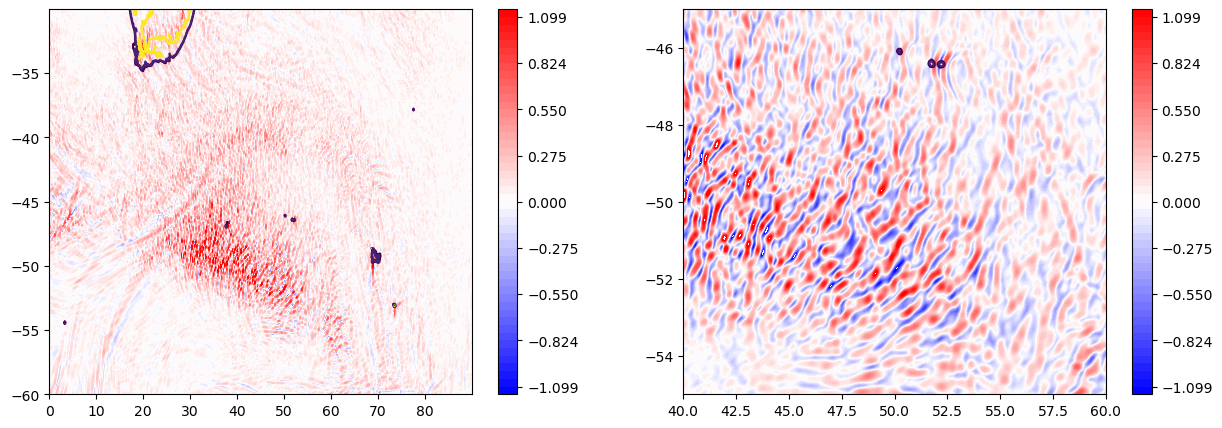

In [23]:

wmax = np.nanpercentile(np.abs(wp_yx), 99)
levels = 2*np.linspace(-wmax, wmax, 51)



fig,axs=plt.subplots(1,2,figsize=(15,5) )
ax=axs[0]



co=ax.contourf(lon2d,lat2d,-wp_yx,cmap='bwr',levels=levels)
ax.contour(lon2d,lat2d,topo_yx,levels=[10,100,1000])
#plt.xlim(40,60)
#plt.ylim(-55,-45)
plt.colorbar(co)

ax=axs[1]
co=ax.contourf(lon2d,lat2d,wp_yx,cmap='bwr',levels=levels)
ax.contour(lon2d,lat2d,topo_yx,levels=[10,100,1000])
plt.xlim(40,60)
plt.ylim(-55,-45)
plt.colorbar(co)



CPU times: user 154 ms, sys: 11.9 ms, total: 166 ms
Wall time: 203 ms


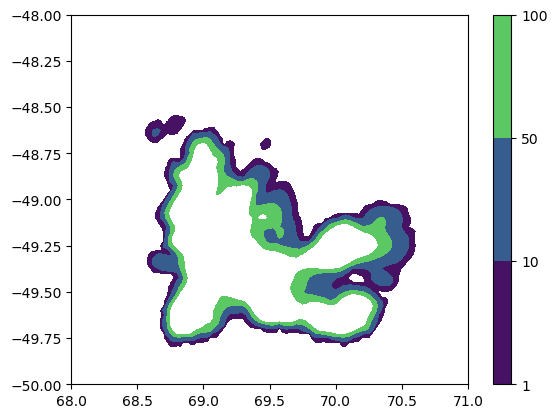

In [20]:
%%time
plt.contourf( lon2d, lat2d , topo_yx ,levels=[1,10,50,100]) 
#plt.contourf( topo_2D, levels=[1,10,50,100] ) 
plt.xlim( 68,71)
plt.ylim( -50,-48 ) 
#plt.ylim(400,500)
plt.colorbar()

In [21]:
# ── 5. USE IT ─────────────────────────────────────────────────────────────────
for t in range(ntime):
    for k in range(len(target_heights)):
        field_all[t, k] = regrid(
            ds_levs["your_var"].isel(Time=t).isel({lev_coord: k}).values
        )

NameError: name 'ntime' is not defined

In [ ]:
%%time
"""data_2d shape: (nCells, nVertLevels)"""
nlevs = wp.shape[1]
wp_zyx = np.empty((len(lat_out), len(lon_out), nlevs))
for k in range(nlevs):
    wp_zyx[..., k] = griddata(points, wp[0,k,:], (lon2d, lat2d), method="linear")